In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
nav = pd.read_csv(
    "../data/processed/clean_nav.csv"
)

nav['date'] = pd.to_datetime(
    nav['date']
)

print(nav.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [4]:
selected_funds = [
    119551,  # SBI Bluechip
    120503,  # ICICI Bluechip
    118632,  # Nippon Large Cap
    119092,  # Axis Bluechip
    120841   # Kotak Bluechip
]

In [5]:
nav = nav[
    nav['amfi_code'].isin(selected_funds)
]

In [6]:
pivot = nav.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

pivot.head()

amfi_code,118632,119092,119551,120503,120841
date,,,,,
2022-01-03,42.8339,38.7466,54.3856,55.3983,275.8370
2022-01-04,42.8033,38.4924,54.3474,55.6327,276.8163
2022-01-05,43.0564,38.2033,54.6869,55.9527,276.3892
2022-01-06,43.2088,38.5825,55.4550,56.6067,278.9247
2022-01-07,42.9585,38.9425,55.3692,57.5741,281.1488


In [7]:
returns = pivot.pct_change().dropna()

returns.head()

amfi_code,118632,119092,119551,120503,120841
date,,,,,
2022-01-04,-0.000714,-0.006561,-0.000702,0.004231,0.003550
2022-01-05,0.005913,-0.007511,0.006247,0.005752,-0.001543
2022-01-06,0.003540,0.009926,0.014045,0.011688,0.009174
2022-01-07,-0.005793,0.009331,-0.001547,0.017090,0.007974
2022-01-10,0.006360,-0.009961,-0.001548,0.001617,-0.021464


In [8]:
mean_returns = returns.mean() * 252

cov_matrix = returns.cov() * 252

print(mean_returns)

amfi_code
118632    0.218037
119092    0.069295
119551    0.231033
120503    0.175794
120841    0.131548
dtype: float64


In [9]:
num_portfolios = 5000

results = []

for i in range(num_portfolios):

    weights = np.random.random(5)

    weights /= np.sum(weights)

    portfolio_return = np.sum(
        weights * mean_returns
    )

    portfolio_risk = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                cov_matrix,
                weights
            )
        )
    )

    sharpe = (
        portfolio_return /
        portfolio_risk
    )

    results.append([
        portfolio_return,
        portfolio_risk,
        sharpe
    ])

In [10]:
portfolios = pd.DataFrame(
    results,
    columns=[
        'return',
        'risk',
        'sharpe'
    ]
)

portfolios.head()

,return,risk,sharpe
0,0.163005,0.063545,2.565202
1,0.158462,0.067525,2.346707
2,0.134918,0.075096,1.796611
3,0.153132,0.064635,2.369179
4,0.153135,0.071679,2.136400


In [11]:
best = portfolios.loc[
    portfolios['sharpe'].idxmax()
]

print(best)

return    0.187646
risk      0.064382
sharpe    2.914576
Name: 1920, dtype: float64


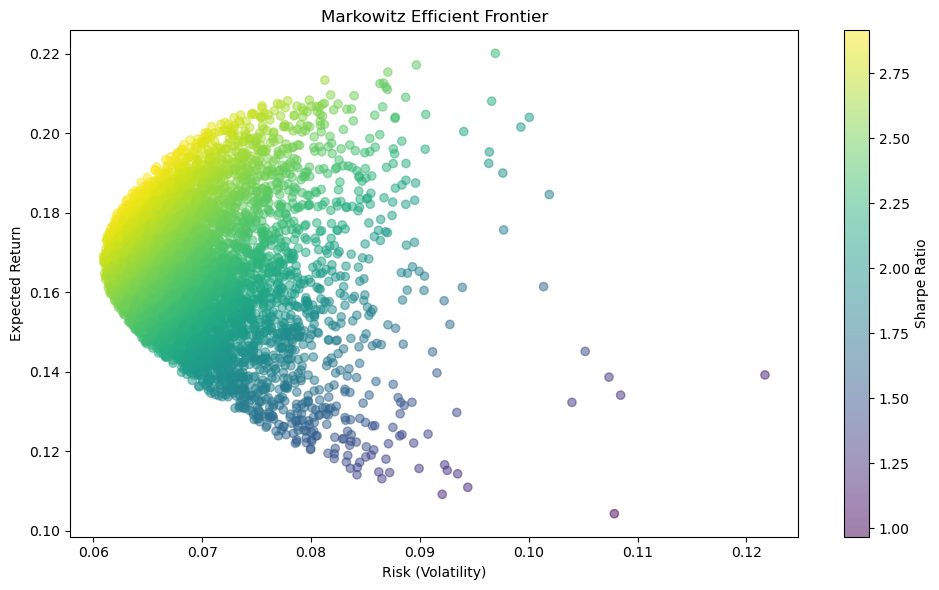

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(
    portfolios['risk'],
    portfolios['return'],
    c=portfolios['sharpe'],
    alpha=0.5
)

plt.colorbar(
    label='Sharpe Ratio'
)

plt.xlabel(
    'Risk (Volatility)'
)

plt.ylabel(
    'Expected Return'
)

plt.title(
    'Markowitz Efficient Frontier'
)

plt.tight_layout()

plt.savefig(
    '../reports/efficient_frontier.png',
    dpi=150
)

plt.show()

In [13]:
best.to_frame().T.to_csv(
    "../data/processed/optimal_portfolio.csv",
    index=False
)

## Markowitz Portfolio Optimisation Observation

A total of 5,000 random portfolios were simulated using five large-cap mutual funds. The Efficient Frontier demonstrates the relationship between expected return and portfolio risk. The portfolio with the highest Sharpe Ratio provides the best risk-adjusted return and represents the optimal allocation among the selected funds. The analysis highlights the importance of diversification in reducing overall portfolio risk.